In [3]:
!pip install statsbombpy
!pip install mplsoccer
!pip install pandas
!pip install matplotlib
!pip install numpy

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 7.3 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.9 MB 7.4 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.9 MB 7.5 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.9 MB 7.7 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.9 MB 7.2 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 6.4 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 5.9 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 5.2 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 4.9 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.9 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 4.2 MB/s  0:00:02
   -------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----------------- ---------------------- 4.2/9.5 MB 22.3 MB/s eta 0:00:01
   --------------------- ------------------ 5.0/9.5 MB 12.2 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.5 MB 9.4 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 7.9 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 7.0 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.5 MB 6.4 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 5.3 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.3 MB 2.9 MB/s eta 0:00:01
   -------------------------- ------------- 1.6/2.3 MB 3.8 MB/s eta 0:00:01
   ------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
from statsbombpy import sb
from mplsoccer import Pitch
import pandas as pd
import matplotlib.pyplot as plt

print("All good. Let's go.")

All good. Let's go.


In [5]:
competitions = sb.competitions()
print(competitions[['competition_name', 'season_name', 'competition_id', 'season_id']].to_string())

           competition_name season_name  competition_id  season_id
0             1. Bundesliga   2023/2024               9        281
1             1. Bundesliga   2015/2016               9         27
2    African Cup of Nations        2023            1267        107
3          Champions League   2018/2019              16          4
4          Champions League   2017/2018              16          1
5          Champions League   2016/2017              16          2
6          Champions League   2015/2016              16         27
7          Champions League   2014/2015              16         26
8          Champions League   2013/2014              16         25
9          Champions League   2012/2013              16         24
10         Champions League   2011/2012              16         23
11         Champions League   2010/2011              16         22
12         Champions League   2009/2010              16         21
13         Champions League   2008/2009              16       

In [6]:
matches = sb.matches(competition_id=43, season_id=106)
print(matches[['match_id', 'home_team', 'away_team', 'home_score', 'away_score']].to_string())

    match_id      home_team      away_team  home_score  away_score
0    3857276         Canada        Morocco           1           2
1    3857271        England           Iran           6           2
2    3857296        Croatia        Belgium           0           0
3    3857274    Netherlands        Ecuador           1           1
4    3857255          Japan          Spain           2           1
5    3857272        England  United States           0           0
6    3857278           Iran  United States           0           1
7    3857277        Morocco        Croatia           0           0
8    3857273          Wales           Iran           0           2
9    3857275        Tunisia         France           1           0
10   3857261          Wales        England           0           3
11   3857290    Switzerland       Cameroon           1           0
12   3857298       Portugal          Ghana           3           2
13   3857285        Senegal    Netherlands           0        

In [7]:
matches = sb.matches(competition_id=43, season_id=106)
final = matches[(matches['home_team'] == 'Argentina') & (matches['away_team'] == 'France')]
print(final[['match_id', 'home_team', 'away_team', 'home_score', 'away_score']])

    match_id  home_team away_team  home_score  away_score
27   3869685  Argentina    France           3           3


In [8]:
events = sb.events(match_id=3869685)
print(events.shape)
print(events['type'].value_counts())

(4407, 94)
type
Pass               1263
Ball Receipt*      1114
Carry               940
Pressure            361
Ball Recovery       115
Duel                 98
Dribble              54
Block                50
Foul Committed       48
Clearance            45
Foul Won             44
Goal Keeper          44
Shot                 38
Miscontrol           35
Dispossessed         34
Dribbled Past        31
Interception         28
Substitution         13
Half Start           10
Half End             10
Injury Stoppage       9
50/50                 8
Tactical Shift        7
Starting XI           2
Bad Behaviour         2
Player Off            1
Player On             1
Offside               1
Shield                1
Name: count, dtype: int64


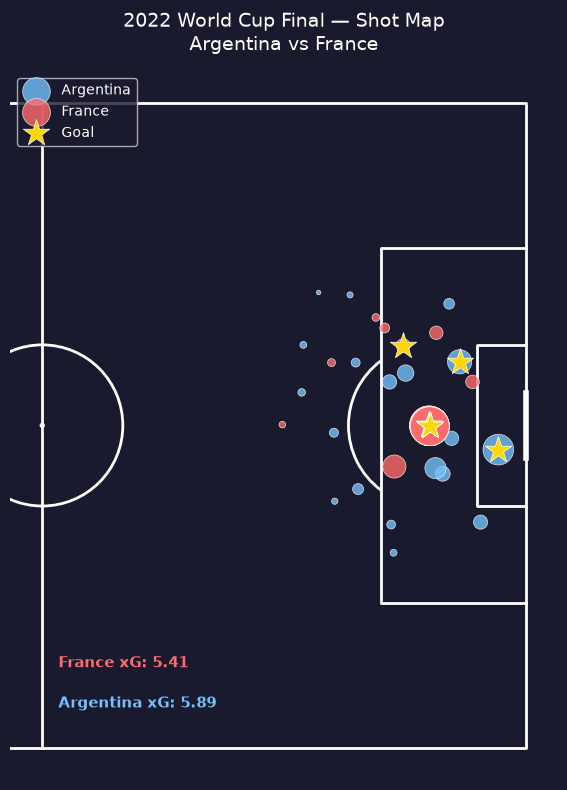

Saved!


In [10]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Filter only shots
shots = events[events['type'] == 'Shot'].copy()

# Extract xG and coordinates
shots['x'] = shots['location'].apply(lambda loc: loc[0])
shots['y'] = shots['location'].apply(lambda loc: loc[1])
shots['xg'] = shots['shot_statsbomb_xg']

# Separate by team
argentina = shots[shots['team'] == 'Argentina']
france = shots[shots['team'] == 'France']

# Draw half pitch (attacking direction)
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1a2e', line_color='white', half=True)
fig, ax = pitch.draw(figsize=(12, 8))
fig.patch.set_facecolor('#1a1a2e')

# Plot Argentina shots (light blue)
pitch.scatter(argentina['x'], argentina['y'],
              s=argentina['xg'] * 1000,
              c='#74c0fc', edgecolors='white', linewidth=0.5,
              alpha=0.8, ax=ax, zorder=3, label='Argentina')

# Plot France shots (red)
pitch.scatter(france['x'], france['y'],
              s=france['xg'] * 1000,
              c='#ff6b6b', edgecolors='white', linewidth=0.5,
              alpha=0.8, ax=ax, zorder=3, label='France')

# Mark goals with a star
goals = shots[shots['shot_outcome'] == 'Goal']
pitch.scatter(goals['x'], goals['y'],
              s=400, c='gold', marker='*',
              edgecolors='white', linewidth=0.5,
              ax=ax, zorder=4, label='Goal')

# Labels
ax.set_title('2022 World Cup Final — Shot Map\nArgentina vs France',
             color='white', fontsize=14, pad=15)
ax.legend(loc='upper left', facecolor='#1a1a2e', labelcolor='white', fontsize=10)

# Add xG totals
arg_xg = argentina['xg'].sum()
fra_xg = france['xg'].sum()
ax.text(62, 75, f'Argentina xG: {arg_xg:.2f}', color='#74c0fc', fontsize=11, fontweight='bold')
ax.text(62, 70, f'France xG: {fra_xg:.2f}', color='#ff6b6b', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('world_cup_final_shotmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

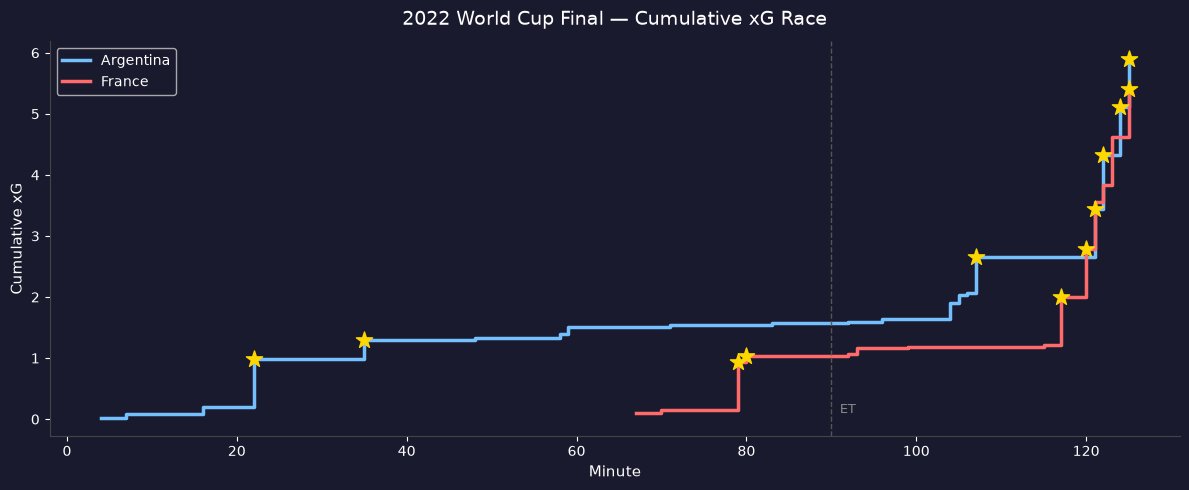

Saved!


In [11]:
import numpy as np

# Get shots with minute and xG
shots = events[events['type'] == 'Shot'].copy()
shots['minute_'] = shots['minute']
shots['xg'] = shots['shot_statsbomb_xg']

argentina_shots = shots[shots['team'] == 'Argentina'].sort_values('minute_')
france_shots = shots[shots['team'] == 'France'].sort_values('minute_')

# Cumulative xG
argentina_shots['cumxg'] = argentina_shots['xg'].cumsum()
france_shots['cumxg'] = france_shots['xg'].cumsum()

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

ax.step(argentina_shots['minute_'], argentina_shots['cumxg'],
        where='post', color='#74c0fc', linewidth=2.5, label='Argentina')
ax.step(france_shots['minute_'], france_shots['cumxg'],
        where='post', color='#ff6b6b', linewidth=2.5, label='France')

# Mark goals
goals = shots[shots['shot_outcome'] == 'Goal']
for _, g in goals.iterrows():
    team_shots = argentina_shots if g['team'] == 'Argentina' else france_shots
    cum = team_shots[team_shots['minute_'] <= g['minute_']]['cumxg'].max()
    color = '#74c0fc' if g['team'] == 'Argentina' else '#ff6b6b'
    ax.scatter(g['minute_'], cum, color='gold', s=150, zorder=5, marker='*')

# Styling
ax.set_title('2022 World Cup Final — Cumulative xG Race', color='white', fontsize=14, pad=12)
ax.set_xlabel('Minute', color='white', fontsize=11)
ax.set_ylabel('Cumulative xG', color='white', fontsize=11)
ax.tick_params(colors='white')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#444')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=10)
ax.axvline(90, color='#555', linestyle='--', linewidth=1, label='90 mins')
ax.text(91, 0.1, 'ET', color='#888', fontsize=9)

plt.tight_layout()
plt.savefig('world_cup_final_xg_race.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")